# 03 - Full Model Comparison

Every model in the registry, evaluated on Dissolved Oxygen forecasting at the final
(`full_features`) pipeline stage. Loads `experiments/results/model_comparison.json`
(produced by `experiments/run_ablation.py`) for the headline table and charts,
then retrains the tree ensembles (for feature importance) and the six deep
learning models (for loss curves) directly in this notebook - both of those
figures need access to the fitted model object / training history, which the
JSON results file intentionally doesn't carry.

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RESULTS_DIR, PRIMARY_TARGET, BASELINE_SARIMAX_MAE, BASELINE_PROPHET_MAE
from src.pipeline import build_base_artifacts, build_stage_dataframe, prepare_model_data
from src.models.registry import build_model, STATISTICAL_MODELS, CLASSICAL_ML_MODELS, DEEP_LEARNING_MODELS

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

comparison = pd.DataFrame(json.load(open(RESULTS_DIR / 'model_comparison.json')))
comparison.head()

I0000 00:00:1784383784.195167  165287 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784383784.195554  165287 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784383784.226060  165287 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784383784.918303  165287 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784383784.918539  165287 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


,target,model,status,train_time_seconds,n_train,n_test,test_mae,test_rmse,test_mape,test_r2,test_n,vs_sarimax_baseline_mae,vs_sarimax_baseline_pct_improvement,vs_prophet_baseline_mae,vs_prophet_baseline_pct_improvement
0,Dissolved Oxygen,persistence,ok,0.02,14809,3174,0.202946,0.278529,2.936014,0.700810,3174,0.6,66.18,0.4,49.26
1,Dissolved Oxygen,linear_regression,ok,0.12,14809,3174,0.096577,0.132803,1.399905,0.931982,3174,0.6,83.90,0.4,75.86
2,Dissolved Oxygen,ridge,ok,0.11,14809,3174,0.096885,0.133129,1.404265,0.931648,3174,0.6,83.85,0.4,75.78
3,Dissolved Oxygen,lasso,ok,2.52,14809,3174,0.099840,0.136541,1.444897,0.928100,3174,0.6,83.36,0.4,75.04
4,Dissolved Oxygen,arima,ok,0.67,6905,1480,0.605840,0.762189,10.297196,-0.459703,1480,0.6,-0.97,0.4,-51.46


## 1. Full comparison table

In [2]:
def category_of(name):
    if name in STATISTICAL_MODELS:
        return 'Statistical'
    if name in CLASSICAL_ML_MODELS:
        return 'Classical ML'
    if name in DEEP_LEARNING_MODELS:
        return 'Deep Learning'
    return 'Other'

ok = comparison[comparison['status'] == 'ok'].copy()
ok['category'] = ok['model'].apply(category_of)
ok = ok.sort_values('test_mae')
ok[['model', 'category', 'test_mae', 'test_rmse', 'test_mape', 'test_r2', 'n_test', 'train_time_seconds']]

,model,category,test_mae,test_rmse,test_mape,test_r2,n_test,train_time_seconds
1,linear_regression,Statistical,0.096577,0.132803,1.399905,0.931982,3174,0.12
2,ridge,Statistical,0.096885,0.133129,1.404265,0.931648,3174,0.11
3,lasso,Statistical,0.099840,0.136541,1.444897,0.928100,3174,2.52
11,lightgbm,Classical ML,0.116091,0.156637,1.678300,0.905377,3174,2.18
10,xgboost,Classical ML,0.117363,0.158154,1.697618,0.903536,3174,2.86
8,random_forest,Classical ML,0.119271,0.162298,1.730656,0.898414,3174,16.53
9,gradient_boosting,Classical ML,0.128287,0.172142,1.852945,0.885717,3174,74.20
12,catboost,Classical ML,0.136279,0.181900,1.970692,0.872394,3174,1.29
7,svr,Classical ML,0.176593,0.223203,2.504326,0.807865,3174,9.16
0,persistence,Statistical,0.202946,0.278529,2.936014,0.700810,3174,0.02


In [3]:
failed = comparison[comparison['status'] != 'ok']
if len(failed):
    print("Models that did NOT produce a usable result (reported explicitly, not silently dropped):")
    display(failed[['target', 'model', 'status']])
else:
    print(f"Every model in the registry ({len(ok)}/{len(ok)}) produced a usable result.")

Every model in the registry (20/20) produced a usable result.


## 2. Bar chart - test MAE by model

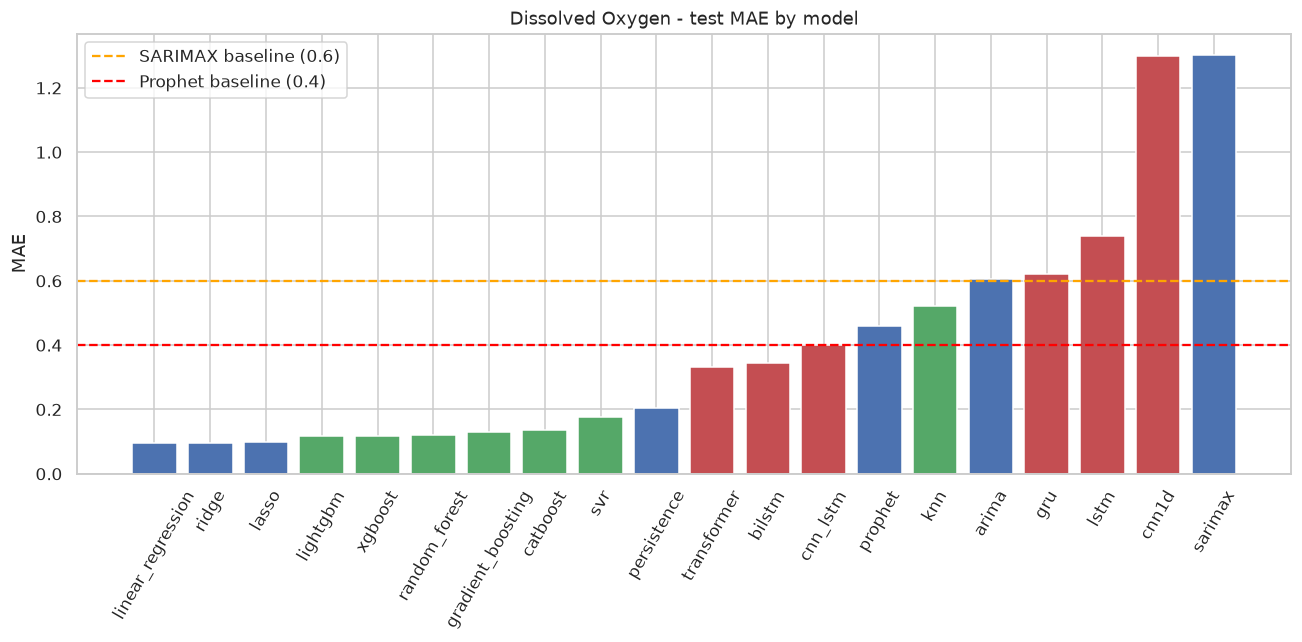

In [4]:
sub = ok.sort_values('test_mae')
colors = sub['category'].map({'Statistical': '#4C72B0', 'Classical ML': '#55A868', 'Deep Learning': '#C44E52'})
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(sub['model'], sub['test_mae'], color=colors)
ax.set_title('Dissolved Oxygen - test MAE by model')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=60)
ax.axhline(BASELINE_SARIMAX_MAE, color='orange', linestyle='--', label=f'SARIMAX baseline ({BASELINE_SARIMAX_MAE})')
ax.axhline(BASELINE_PROPHET_MAE, color='red', linestyle='--', label=f'Prophet baseline ({BASELINE_PROPHET_MAE})')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/model_comparison_mae.png', bbox_inches='tight')
plt.show()

## 3. Best model vs published baseline

In [5]:
best_row = ok.loc[ok['test_mae'].idxmin()]
print(f"Best model = {best_row['model']} (MAE={best_row['test_mae']:.4f}, R2={best_row['test_r2']:.4f})")
sarimax_improve = (BASELINE_SARIMAX_MAE - best_row['test_mae']) / BASELINE_SARIMAX_MAE * 100
prophet_improve = (BASELINE_PROPHET_MAE - best_row['test_mae']) / BASELINE_PROPHET_MAE * 100
print(f"  vs SARIMAX baseline ({BASELINE_SARIMAX_MAE}): {sarimax_improve:+.1f}%")
print(f"  vs Prophet baseline ({BASELINE_PROPHET_MAE}): {prophet_improve:+.1f}%")

Best model = linear_regression (MAE=0.0966, R2=0.9320)
  vs SARIMAX baseline (0.6): +83.9%
  vs Prophet baseline (0.4): +75.9%


## 4. Feature importance - tree ensembles

Retrains the tree-based models directly since `SklearnRegressorAdapter.feature_importances()`
needs the fitted estimator object, not just its scored metrics.

2026-07-18 19:39:45,698 | INFO     | src.data_loader | Loading raw CSV from /home/icarus/DO_Predictor/data/raw/brisbane_water_quality.csv


2026-07-18 19:39:45,745 | INFO     | src.data_loader | Dropped pH column(s) ['pH', 'pH [quality]'] - this system is Dissolved-Oxygen-only.


2026-07-18 19:39:45,746 | INFO     | src.data_loader | Loaded 30894 rows, 18 columns.


2026-07-18 19:39:45,758 | INFO     | src.validation | Validation done: 30894 rows, 280 dup timestamps, 7 quality cols kept, 0 dropped, modal cadence=10.0 min.


2026-07-18 19:39:45,759 | INFO     | src.validation | note: 280 duplicate Timestamp values (different Record numbers, same clock reading) - resolved in cleaning.py.


...

2026-07-18 19:39:45,830 | INFO     | src.cleaning | Flagged 435 outlier readings across all sensors (not dropped).


2026-07-18 19:39:45,831 | INFO     | src.cleaning | Cleaning pipeline complete: 47149 rows in final frame.


2026-07-18 19:39:45,854 | INFO     | src.smoothing | Added moving-average and Savitzky-Golay columns for 9 sensors.


2026-07-18 19:39:45,923 | INFO     | src.pipeline | Cached processed dataset to /home/icarus/DO_Predictor/data/processed/brisbane_water_quality_clean.parquet


2026-07-18 19:39:46,182 | INFO     | src.feature_engineering | Built feature matrix: 165 columns for target 'Dissolved Oxygen'.


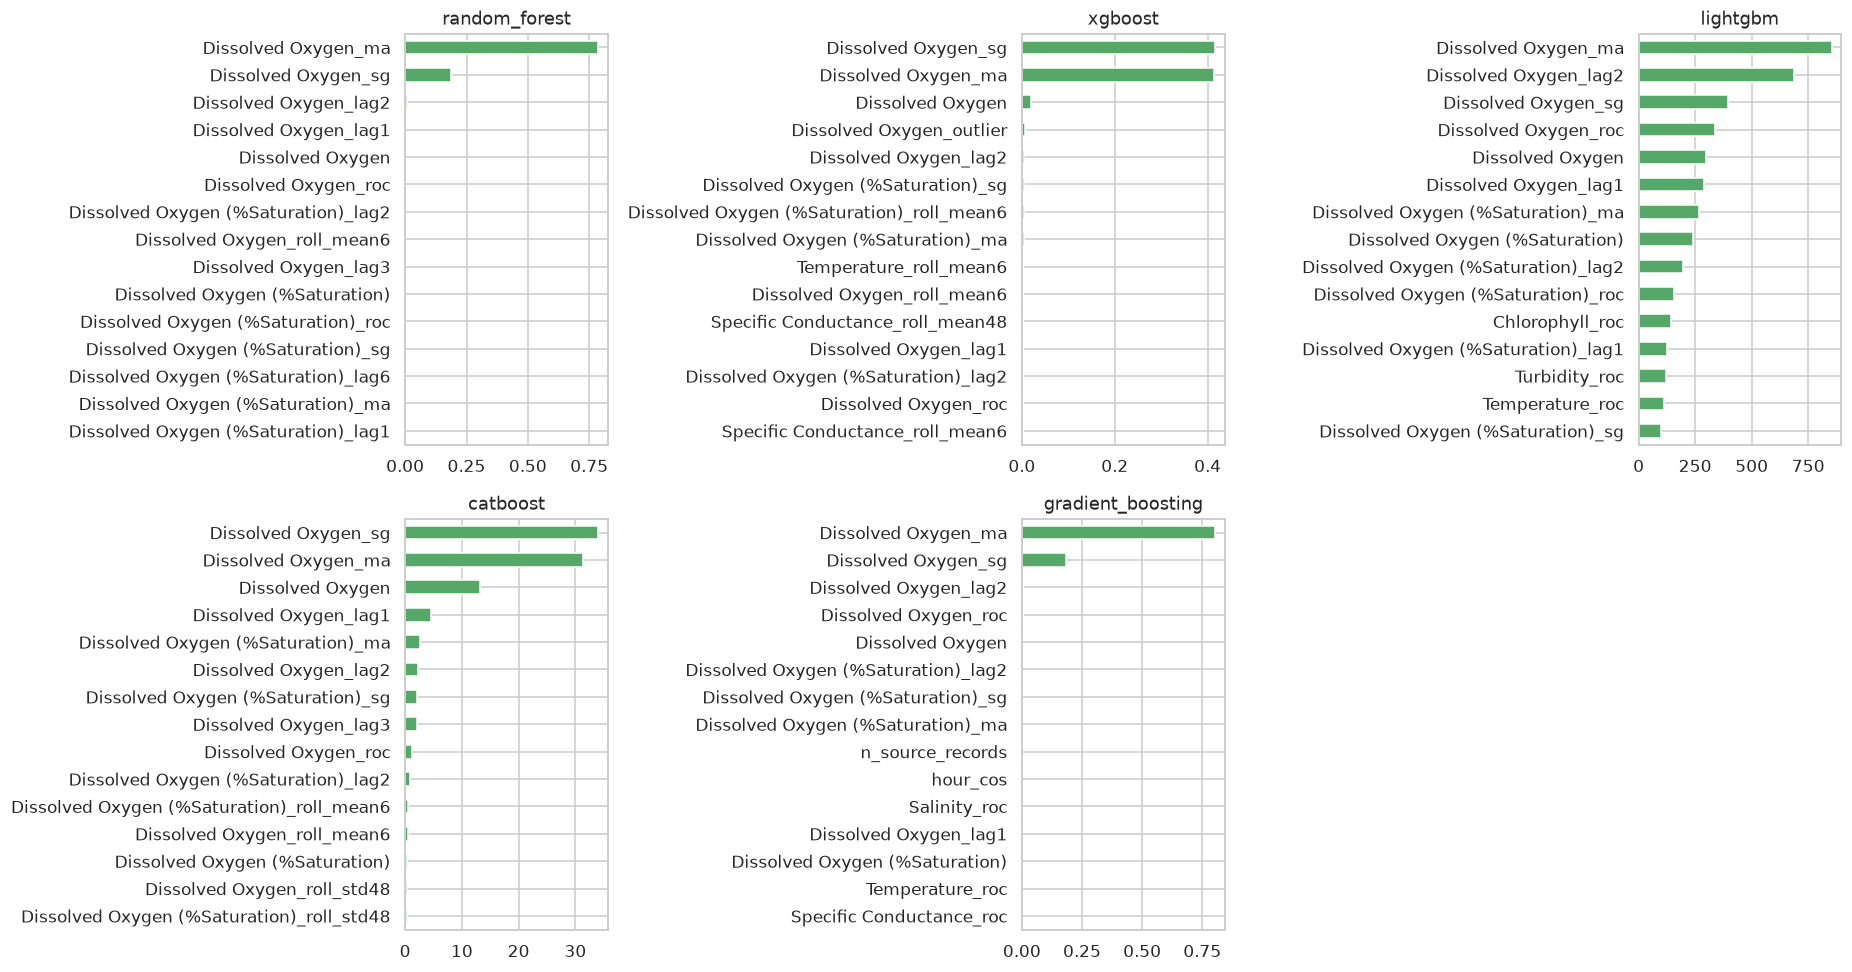

In [6]:
from src.models.random_forest import build_random_forest
from src.models.xgboost_model import build_xgboost
from src.models.lightgbm_model import build_lightgbm
from src.models.catboost_model import build_catboost
from src.models.gradient_boosting import build_gradient_boosting

base = build_base_artifacts()
stage_df = build_stage_dataframe(base, PRIMARY_TARGET, 'full_features')
splits = prepare_model_data(stage_df, PRIMARY_TARGET, 'random_forest')
X_train, y_train = splits['train']
X_val, y_val = splits['val']

tree_builders = {
    'random_forest': build_random_forest,
    'xgboost': build_xgboost,
    'lightgbm': build_lightgbm,
    'catboost': build_catboost,
    'gradient_boosting': build_gradient_boosting,
}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (name, builder) in zip(axes.flat, tree_builders.items()):
    model = builder(PRIMARY_TARGET)
    model.fit(X_train, y_train, X_val, y_val)
    importances = model.feature_importances()
    top = pd.Series(importances).sort_values(ascending=False).head(15)
    top.iloc[::-1].plot(kind='barh', ax=ax, color='#55A868')
    ax.set_title(name)
for ax in axes.flat[len(tree_builders):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../reports/feature_importance_trees.png', bbox_inches='tight')
plt.show()

## 5. Training / validation loss curves - deep learning models

Retrains all six sequence models to capture Keras training history (not
persisted in the JSON results). Takes a few minutes.

E0000 00:00:1784383883.046023  165287 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


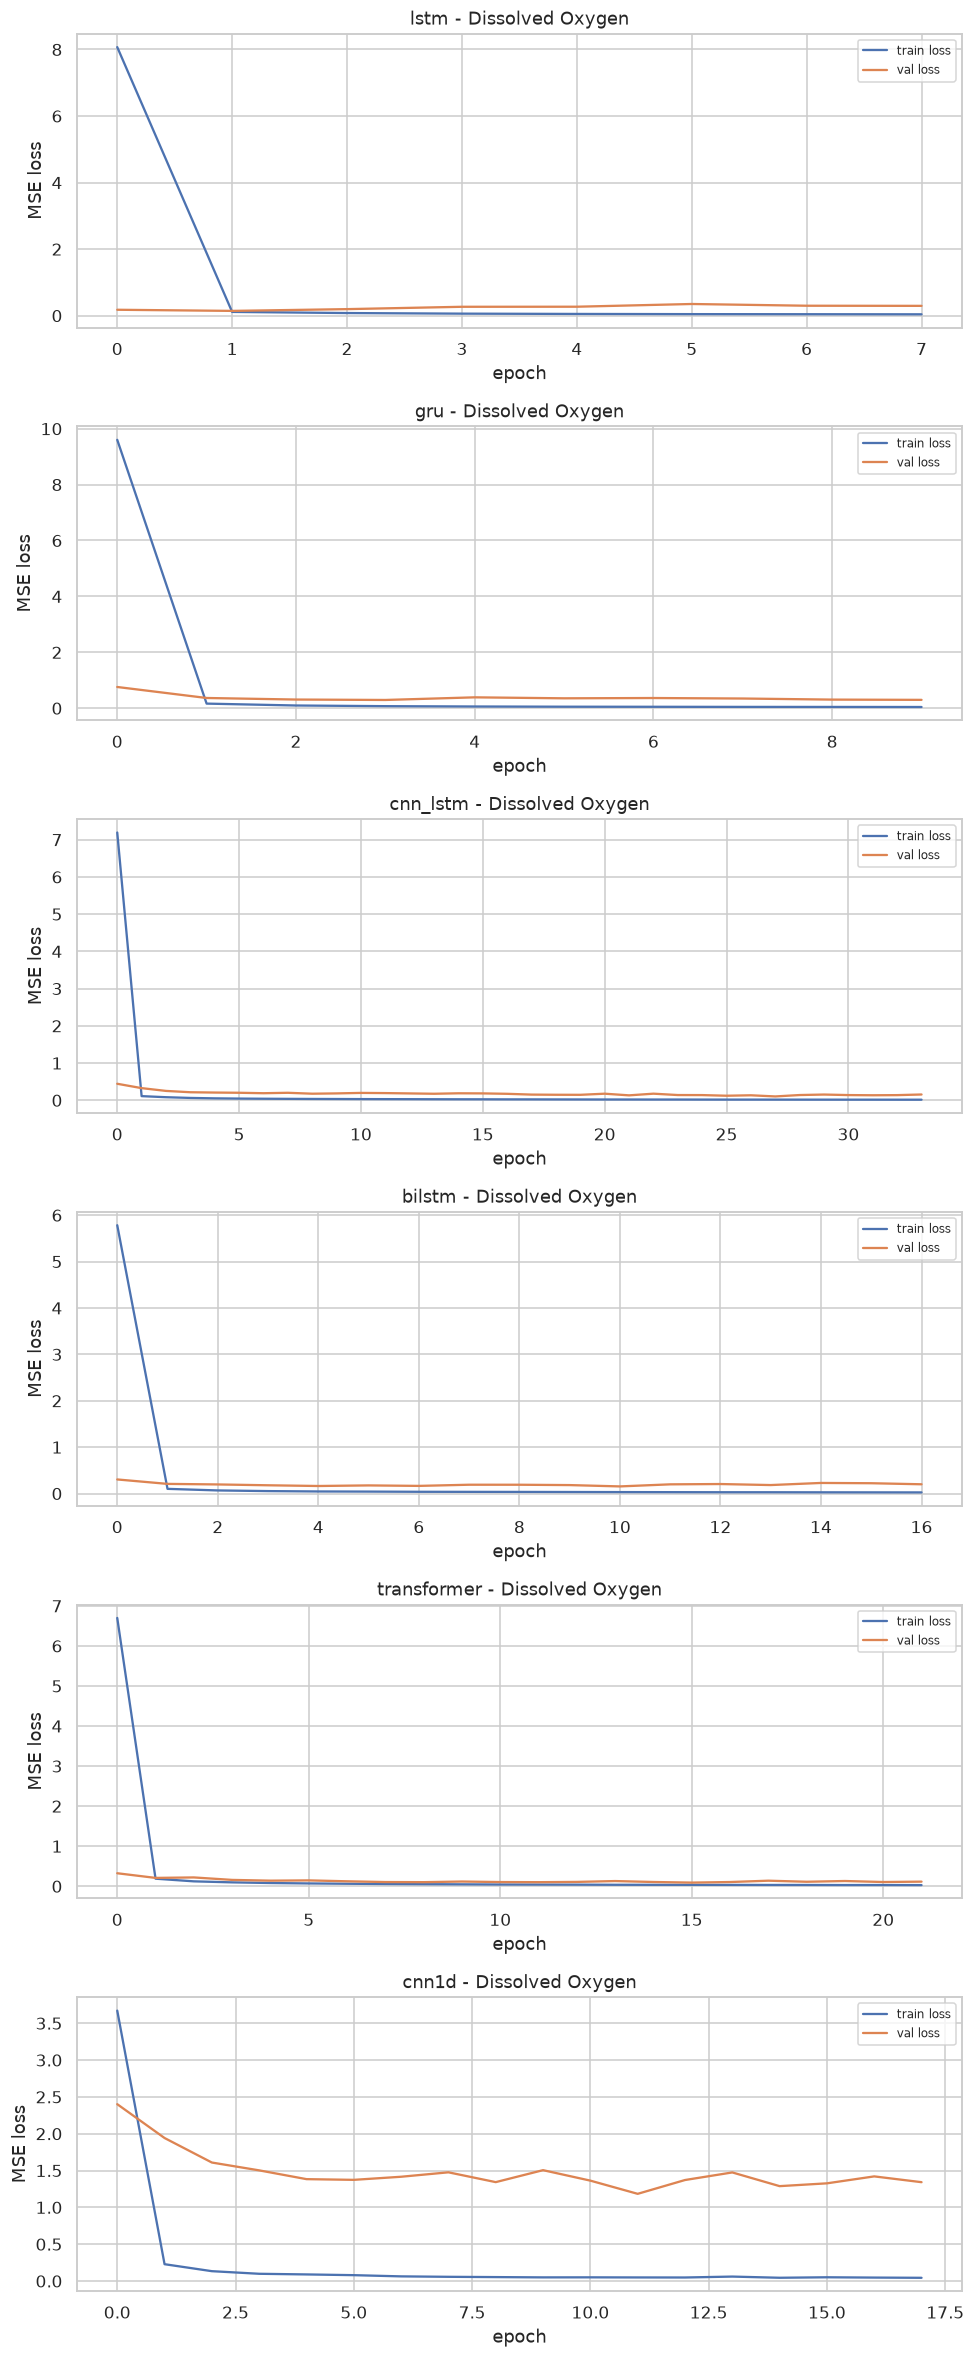

In [7]:
dl_builders = DEEP_LEARNING_MODELS

fig, axes = plt.subplots(len(dl_builders), 1, figsize=(9, 3.6 * len(dl_builders)))
for ax, (name, builder) in zip(axes, dl_builders.items()):
    splits_t = prepare_model_data(stage_df, PRIMARY_TARGET, name)
    X_train_t, y_train_t = splits_t['train']
    X_val_t, y_val_t = splits_t['val']

    model = builder(PRIMARY_TARGET)
    model.fit(X_train_t, y_train_t, X_val_t, y_val_t)

    ax.plot(model.history_['loss'], label='train loss')
    if 'val_loss' in model.history_:
        ax.plot(model.history_['val_loss'], label='val loss')
    ax.set_title(f'{name} - Dissolved Oxygen')
    ax.set_xlabel('epoch')
    ax.set_ylabel('MSE loss')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/dl_loss_curves.png', bbox_inches='tight')
plt.show()

## Summary

Sections 1-3 give the headline thesis result: full registry ranked against each
other and against the cited SARIMAX/Prophet public baseline. Section 4 checks
which engineered features the tree ensembles actually lean on (sanity check
against domain expectations - lagged DO/temperature should dominate). Section 5
confirms the deep learning models are converging rather than just running out of
epochs with a still-falling loss curve.